
# Tutorial Outline: Spectral Embedding Methods

## 1. Introduction

* **Motivation:**

  * Mass spectra are sparse, high-dimensional signals.
  * To analyze them efficiently, we need to transform spectra into lower-dimensional, machine-readable embeddings.
  
* **Learning Goals:**

  * Understand X approaches to spectral embedding.
  * See how dimensionality reduction and embeddings enable clustering, visualization, and downstream ML tasks.

Below, you'll find some code to get you started. (Code was mostly taken from [Lesson 4](https://colab.research.google.com/drive/13WEV58HpkY7f0kFi2BA5ia5p0XZCL3Cq?authuser=1#scrollTo=FYgmwfThBQJJ))

In the context of this tutorial, the most useful end result from these functions is the MS2 spectrum object, as well as to serve as examples for how to use pyteomics

In [9]:
%pip install pyteomics
%pip install plotly==5.18.0
%pip install pandas
%pip install spectrum_utils==0.4.2
%pip install scikit-learn
%pip install rapidhash


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [18]:
# @title Run this cell to download parent Google drive contents
import spectrum_utils.plot as sup
import spectrum_utils.spectrum as sus
import pyteomics
from pyteomics import mzml, auxiliary
import gdown
import plotly.io as pio
import plotly.tools as tls
import plotly.graph_objects as go
import pandas as pd
import random
import numpy as np
from rapidhash import rapidhash

In [19]:
# @title Run this cell to create our amino acid dictionary (from Lesson 1).
aa_mass = {'A': 71.037114, 'R':156.101111 , 'N': 114.042927,
           'D': 115.026943, 'C': 103.009185, 'E': 129.042593,
           'Q' : 128.058578, 'G': 57.021464, 'H': 137.058912,
           'I': 113.084064, 'L': 113.084064, 'K': 128.094963,
           'M' : 131.040485, 'F':  147.068414, 'P':  97.052764,
           'S': 87.032028, 'T': 101.047679, 'U': 150.95363,
           'W': 186.079313, 'Y': 163.06332, 'V': 99.068414}

In [20]:
# @title Run this cell to declare a function that creates a b-/y-ion ladder for a peptide.

# This will make a b/y ion ladder for any given peptide and put it in a dataframe
def make_ion_ladder(peptide, aa_mass):
    b_ions = {}
    y_ions = {}

    mass_Hydrogen = 1.0078
    mass_Oxygen = 15.994915
    proton_mass = 1.007

    '''
    Note: In the following functions, if you look closely to the calculations,
    you will see some additions of protons that are different to what we did in
    lesson 1 & 2. This is because instead of enzymatically digesting a protein,
    we are violently fragmenting the peptides milliseconds before measuring them.
    The physics is a little more complicated, so don't worry too much about it.

    If you really want to know the chemistry/physics behind this, you can read
    about it in this paper: https://cse.sc.edu/~rose/790B/papers/dancik.pdf
    '''
    # Generate b-ions
    b_mass_current = 0
    b_ion = ''
    fragment = 0
    for aa in peptide:
        b_ion += aa
        if (b_ion != peptide):
          b_mass_current += aa_mass[aa]
          b_ions[b_ion] = b_mass_current + proton_mass # mass of the charge on fragment

    # Generate y-ions
    y_mass_current = mass_Hydrogen + mass_Oxygen #adds terminal OH
    y_mass_current += proton_mass
    y_ion = ''
    fragment = 0
    for aa in peptide[::-1]:
        y_ion += aa
        if (y_ion[::-1] != peptide):
          y_mass_current += aa_mass[aa]
          y_ions[y_ion[::-1]] = y_mass_current + proton_mass #mass of charge on fragment

    # Populate dataframe
    data = {
        'b#': [b+1 for b in range(len(peptide)-1)],
        'b_ion_m/z': [b_ions[b_key] for b_key in b_ions.keys()],
        'b_ion_sequence': [b_key for b_key in b_ions.keys()],
        'y_ion_sequence': [y_key for y_key in y_ions.keys()][::-1],
        'y_ion_m/z': [y_ions[y_key] for y_key in y_ions.keys()][::-1],
        'y#': [len(peptide)-i-1 for i in range(len(peptide)-1)]
    }

    # Format dataframe
    df = pd.DataFrame(data)
    # df = df.style.set_properties(
    #     subset=['b_ion_sequence'],
    #     **{'text-align': 'left'}
    # ).format({
    #     'b_ion_m/z': '{:,.2f}',
    #     'y_ion_m/z': '{:,.2f}'
    # }).set_table_styles([{
    #     'selector': 'thead th',
    #     'props': [('vertical-align', 'bottom'), ('text-align', 'left')]
    # }, {
    #     'selector': 'th.index_name',  # targeting the index name specifically
    #     'props': [('vertical-align', 'bottom')]
    # }])

    # print(df)
    return(df)

In [21]:
# @title Run this cell to declare a function that gets an MS2 spectrum object.

def get_MS2_object(mzml_path, scan, peptide = None):
    su_spectrum = None
    with pyteomics.mzml.read(mzml_path) as spectra:
        for spectrum in spectra:
            scanNumber = int(spectrum['id'].split('=')[-1])
            if scanNumber == scan:
                # This finds the cooresponding values in the .mzml file to create our MS2 for a given scan (see the params)
                spectrum_id = spectrum['id']
                mz = spectrum['m/z array']
                intensity = spectrum['intensity array']
                retention_time = spectrum['scanList']['scan'][0]['scan start time']
                precursor_mz = spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
                precursor_charge = int(spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])

                su_spectrum = sus.MsmsSpectrum(spectrum_id, precursor_mz, precursor_charge, mz, intensity, retention_time=retention_time)

                # Process the spectrum
                su_spectrum = (su_spectrum.filter_intensity(0.05, 100)
                               .remove_precursor_peak(fragment_tol_mass=0.5, fragment_tol_mode='Da')
                               .scale_intensity('root'))
                break
    # Formatting
    if su_spectrum:
        fragment_tol_mass = 0.5
        fragment_tol_mode = 'Da'  ## for some reason, if I use 'ppm' it doesn't work

        # If given the peptide, spec_utils can annotate the peaks
        if peptide:
          su_spectrum = su_spectrum.annotate_proforma(peptide, fragment_tol_mass, fragment_tol_mode, ion_types='by', max_ion_charge=2)
    return su_spectrum

In [22]:
# @title Run this cell to declare a function that plots an MS2 spectrum.

def plot_MS2(ms2_spectrum):
    ax = sup.spectrum(ms2_spectrum)
    plotly_fig = tls.mpl_to_plotly(ax.figure)
    plotly_fig['layout']['plot_bgcolor'] = 'white'
    plotly_fig['layout']['xaxis']['showline'] = True
    plotly_fig['layout']['xaxis']['linecolor'] = 'black'
    plotly_fig['layout']['xaxis']['linewidth'] = 2
    plotly_fig['layout']['yaxis']['linecolor'] = 'black'
    plotly_fig['layout']['yaxis']['linewidth'] = 2
    plotly_fig.show()

In [23]:
# This function is defined above in Part 1 - take a look at the code up
#   there to see what it is doing
make_ion_ladder('VLDALDSIK', aa_mass)

,b#,b_ion_m/z,b_ion_sequence,y_ion_sequence,y_ion_m/z,y#
0,1,100.075414,V,LDALDSIK,874.486898,8
1,2,213.159478,VL,DALDSIK,761.402834,7
2,3,328.186421,VLD,ALDSIK,646.375891,6
3,4,399.223535,VLDA,LDSIK,575.338777,5
4,5,512.307599,VLDAL,DSIK,462.254713,4
5,6,627.334542,VLDALD,SIK,347.227770,3
6,7,714.366570,VLDALDS,IK,260.195742,2
7,8,827.450634,VLDALDSI,K,147.111678,1


In [24]:
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN.mzML'
ms2_spectrum_unannotated = get_MS2_object(mzml_path, 5672)
plot_MS2(ms2_spectrum_unannotated)

In [25]:
ms2_spectrum_annotated = get_MS2_object(mzml_path, 5672, peptide = 'VLDALDSIK')
plot_MS2(ms2_spectrum_annotated)


## 2. Method 1: Spectral Hashing

### 2.1 Conceptual Introduction

* Required Reading: https://pubs.acs.org/doi/full/10.1021/acs.jproteome.9b00291
* Begin with **clustering in 2D**: show how points close together can be grouped.
* Extend to **3D embeddings** as an example of higher-dimensional clustering.
* Transition: spectra are naturally high-dimensional; embeddings allow efficient clustering.

### 2.2 From Peaks to Vectors

* Represent a spectrum as a list of *m/z*–intensity pairs.
* Traditional binning: divide the *m/z* axis into bins and assign intensities.
* Limitation: When binning, you have to take a **continuous value** (m/z) and transform it to a **discrete value**. This presents two problems
  * Information is lost! Small differences in the m/z dimension can give very imporant information
  * The same peak can extend across multiple bins. Imagine a peak that is located precisely at 999.999 m/z. Depending on how well/poorly the instrument is calibrated, the same peak can be sorted into different bins
  * To demonstrate this, show how feature hashing fails to differentiate between TMT channels

### 2.3 Feature Hashing for Spectral Embedding

* Use **feature hashing** to map high-resolution bins into a fixed-length vector (e.g., 880 dimensions).
* Each *m/z* bin is hashed into one of the vector’s components, accumulating intensity.
* Benefits:

  * Compact vector representation.
  * Preserves similarity structure for clustering or approximate nearest neighbor (ANN) search.




**Theoretical steps**

The paper simplifies feature hashing down to two main steps:

1. Convert the spectrum to a sparse vector
using small mass bins to tightly capture
fragment masses.
2. Hash the sparse, high-dimensional
vector to a lower- dimensional vector by using a hash
function to map the mass bins to a limited number of hash bins

![fig-1.png](https://pubs.acs.org/cms/10.1021/acs.jproteome.9b00291/asset/images/medium/pr9b00291_0001.gif)

I explain what this means practically, line by line, in the code below.

In [ ]:
# Quick note that spectra is plural, spectrum is singular.
# The getMS2 function takes in a parameter, scan, which chooses a single spectrum of ms2

spectrum_mz = ms2_spectrum_unannotated.mz
'''
Where spectrum_mz =
[129.10374451 147.11447144 185.16696167 186.17019653 213.16217041
 229.1210022  260.20001221 298.14343262 300.1590271  328.190979
 347.23321533 348.23629761 462.26141357 463.26467896 484.20996094
 575.34680176 646.3848877  647.38745117 743.4017334  761.41223145
 762.41516113 763.41802979 874.49749756 875.50030518]
'''
spectrum_int = ms2_spectrum_unannotated.intensity
'''
Where spectrum_int =
[2174.818  3145.84   9230.925  2883.7764 4380.564  2282.9873 3063.1228
 2072.459  3142.8696 2672.6929 5380.33   2240.3975 6059.931  2831.662
 2237.5989 3632.9626 4356.975  2494.9565 2366.8223 8133.1064 5098.785
 2226.6924 4098.929  2766.6738]d
'''
# Intensity and mz values are parallel arrays, which is more clearly visible via the common graphs above, as well as:
assert(len(spectrum_int) == len(spectrum_mz))

Speaking of which, take a look at the (un)annotated spectrum graphs, figure, and theoretical steps above again! Here are some corollaries we can find from them:
- This particular spectrum ranges from mz values from 0 through ~880.
- _Sparse Array_: An array of mostly zeroes, with a few values intermingled throughout the array
- Suppose we wanted to put these mz and intensity values into a sparse array
    - How can we represent both of these things in a single, non 2d array?
        - What if we had len(arr) = 880? And then we round down each mz value to the nearest integer? Then, we'd be able to represent an mz of, say, 129.10374451 in the 128th (0 based) index, and put its corresponding intensity (2174.818) in the 128th spot in the array of len 880.


Remember:

**spectrum_mz =**
[129.10374451 147.11447144 185.16696167 186.17019653 213.16217041
 229.1210022  260.20001221 298.14343262 300.1590271  328.190979
 347.23321533 348.23629761 462.26141357 463.26467896 484.20996094
 575.34680176 646.3848877  647.38745117 743.4017334  761.41223145
 762.41516113 763.41802979 874.49749756 875.50030518]


**spectrum_int =**
[2174.818  3145.84   9230.925  2883.7764 4380.564  2282.9873 3063.1228
 2072.459  3142.8696 2672.6929 5380.33   2240.3975 6059.931  2831.662
 2237.5989 3632.9626 4356.975  2494.9565 2366.8223 8133.1064 5098.785
 2226.6924 4098.929  2766.6738]
```

We'll rewrite this into our new array of length 880 as a numerical example.
*   In the 129th idx: 2174.818
*   In the 147th idx: 3145.84
*   In the 185th idx: 9230.925
*   And so on...

Indices that aren't mapped to anything are zeroed out.

![image](binning_rationale.jpg)


Now, my intention is to give some motivation to why we want more than just 880 values, even though they all work just fine. 
- That is to say, the m/z at 129.4 and 128.5 (both idx=129 if we round to nearest int) _aren't_ colliding because such m/z values don't exist

But what if they were? 
Below, we've modified the get_MS2_object to get_all_MS2_objects in order to show the possibility that multiple m/z values. Even when plotting just a few spectra, we can see that many m/z values are similar.

In [ ]:
def get_all_MS2_objects(mzml_path):
    ms2_spectra = []
    with pyteomics.mzml.read(mzml_path) as spectra:
        for spectrum in spectra:
            # This finds the corresponding values in the .mzml file to create list of ms2 objs
            ms_level = spectrum.get('ms level', 0)  # Use 'ms level' not 'level'
            if ms_level == 2:
                spectrum_id = spectrum['id']  # Use spectrum['id'], not spectrum['ms level'][0]
                mz = spectrum['m/z array']
                intensity = spectrum['intensity array']
                retention_time = spectrum['scanList']['scan'][0]['scan start time']
                precursor_mz = spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
                precursor_charge = int(spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])

                su_spectrum = sus.MsmsSpectrum(spectrum_id, precursor_mz, precursor_charge, mz, intensity, retention_time=retention_time)

                # Process the spectrum
                processed_spectrum = (su_spectrum.filter_intensity(0.05, 100)
                                    .remove_precursor_peak(fragment_tol_mass=0.5, fragment_tol_mode='Da')
                                    .scale_intensity('root'))

                # Add processed spectrum to our list
                ms2_spectra.append(processed_spectrum)


    return ms2_spectra

In [ ]:
all_ms2_spectra = get_all_MS2_objects(mzml_path)
for i, spectrum in enumerate(all_ms2_spectra[:5]):  # Only plot first 5 to avoid overhwelming output.
    print(f"Plotting spectrum {i+1}")
    plot_MS2(spectrum)
    
print (f"There exist {len(all_ms2_spectra)} in this fairly small mzml file - there is an overwhelming chance that multiple m/z values here overlap.")

Plotting spectrum 1


Plotting spectrum 2


Plotting spectrum 3


Plotting spectrum 4


Plotting spectrum 5


There exist 414 in this fairly small mzml file - there is an overwhelming chance that multiple m/z values here overlap.


**Why might we want the indeces to represent more precise mz values?**

1.   List item

In this case then, we'd probably end up with mz values that overlap, especially if rounded to the nearest integer. Eg. all mz 128.5 <= num < 129.5 round to 129. This is why we create buckets.

If we made an array of (880 in this case) len(max(spectrum_mz)) * 10, we'd be able to approximate to the nearest 0.1, not the nearest 1. If we made an array of len(max(spectrum_mz)) * 100, the nearest 0.001.

The more exact, the better, such that intensities don't overlap. I choose 880 * 1000 (accurate to third decimal) somewhat arbitrarily.

_But making an array of **880000** slots sucks, even if it's still accurate._ It's just too computationally expensive.

The above would probably work better for dot products/convolutions/etc. especially for GPUs which like contiguous arrays and they'd probably need to fill them in for most computations.
But we'll try a slightly different approach, one that better follows the actual paper.

In [ ]:
width = 0.001

def to_idx(num): # where num = mz val
    """
    Convert m/z value to a sparse vector index.

    This implements STEP 1 from the theoretical framework:
    "Convert the spectrum to a sparse vector using small mass bins"

    We divide m/z by 0.001 to create bins of 0.001 Da width.
    For example: 129.103 m/z → index 129103
    This creates fine-grained bins that preserve mass accuracy.
    """
    return int(num // 0.001) # round to third decimal and return the result. int since these will be 0 based indices


# IMPORTANT BELOW
# Create the sparse representation: map from m/z indices to intensities
# This is our "sparse vector" - instead of a huge array with mostly zeros,
# we only store the non-zero entries in a dictionary
map = {}

# Populate the sparse vector with our spectrum data
for i, mz in enumerate(spectrum_mz):
    # Convert each m/z to its corresponding index and store the intensity
    map[to_idx(mz)] = spectrum_int[i]

print(spectrum_mz[0], to_idx(spectrum_mz[0]))
# outputs: 129.10374450683594 129103

# Verify our mapping works correctly
assert(map[to_idx(spectrum_mz[0])] == 2174.818) # our expected index correctly matches our intensity. (See mz and intensity arrays!)

'''
Example of what our sparse vector looks like conceptually:
sparse_index → intensity
129103 → 2174.818  (from m/z 129.104)
147114 → 3145.84   (from m/z 147.114)
185166 → 9230.925  (from m/z 185.167)
...

This avoids creating a massive array of ~880,000 zeros with just ~24 non-zero values!
'''

# STEP 2 from theoretical framework: Hash the high-dimensional sparse vector
# to a lower-dimensional vector using a hash function

hash_buckets = 400  # Our target dimensionality (much smaller than ~880k sparse indices)

def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.

    This implements STEP 2: "Hash the sparse, high-dimensional vector to a
    lower-dimensional vector by using a hash function"

    Input: Large sparse index (e.g., 129103)
    Output: Small bucket index (0 to 399)

    Uses rapidhash for good distribution properties.
    """
    # Convert integer to bytes for hashing (rapidhash expects byte input)
    byte_representation = int(num).to_bytes(8, 'little')

    # Hash and modulo to get bucket index in range [0, hash_buckets-1]
    return rapidhash(byte_representation) % hash_buckets

# Initialize our final feature vector (the "embedding")
# This is our compact, fixed-size representation of the spectrum
hash_matrix = [0] * hash_buckets  # Start with all zeros

# The final step: populate the hash buckets with intensities
# Multiple sparse indices may hash to the same bucket (collisions)
# We handle collisions by ADDING intensities (preserving total signal)

for sparse_idx, intensity in map.items():
    # Get the hash bucket for this sparse index
    bucket_idx = hasher(sparse_idx)

    # Add the intensity to the bucket (handles collisions by summation)
    hash_matrix[bucket_idx] += intensity

print("Final spectral hash vector:", hash_matrix)
print("Non-zero buckets:", sum(1 for x in hash_matrix if x > 0))



129.10374450683594 129103
Final spectral hash vector: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, np.float32(2672.6929), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, np.float32(9230.925), 0, 0, np.float32(3063.1228), 0, 0, 0, 0, 0, 0, 0, np.float32(3632.9626), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, np.float32(6059.931), 0, 0, 0, 0, np.float32(2240.3975), 0, np.float32(2174.818), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, np.float32(5380.33), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, np.float32(4380.564), 0, 0, 0, 0, 0, np.float32(4356.975), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, np.float32(4098.929), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, np.float32(2282.9873), np.float32(2766.6738), 0, 0, 0, 0, 0, 0, 0, 0, np.float32(2226.6924), np.float32(2883.

SUMMARY of the spectral hashing process:
1. Started with: 24 (m/z, intensity) pairs
2. Essentially to: ~880,000 possible sparse indices, only 24 actually used
3. Hashed down to: 400 compact feature dimensions
4. Result: Fixed-size vector that preserves spectral similarity for ML/clustering

This 400 dimension vector will largely be used as input to ML models, preserving similarity.

## 3. Method 2: Positional Embedding of Peaks

### 3.1 Motivation

* Required Reading: https://www.nature.com/articles/s41467-024-49731-x
* Simple hashing and binning ignore relative *m/z* spacing.
* Many deep learning models require dense, continuous representations.

### 3.2 Encoding Strategy

* Apply **sinusoidal positional encoding** to each peak’s *m/z* value.
* Each peak is mapped to a **512-dimensional vector**.
* Intensities can be incorporated as additional features or scaling factors.

### 3.3 Applications

* Captures fine-grained relationships between peaks.
* Useful as input to transformer or deep learning architectures for spectral analysis.

## 4. Method 3: Positional Embedding of Augmented Spectra

### 4.1 Motivation

* Required Reading: https://www.nature.com/articles/s41592-025-02718-y
* Relevant signal spans multiple spectra: across retention time (RT) and between MS1 and MS2 levels.
* A richer representation is needed to capture this context.

### 4.2 2D Positional Encoding

* Represent each peak as a tuple: (*m/z*, intensity, RT offset, MS level).
* Apply **2D sinusoidal embeddings** to jointly encode *m/z* and RT.
* Concatenate with learned embeddings for intensity and spectrum level.
* Output: a **512-dimensional embedding** for each peak in the augmented spectrum.





![Each m/z value, m_j, is projected into 512 dimensions](CasanovoEncoding.png)

Positional encoding, as outlined in the Casanovo paper. D = 512

In [38]:
# Define positional encoding function used by Casanovo
# This function takes in 1 m/z value and returns a 512-dimensional positional encoding vector
# (this feels sort of like a reverse Fourier transform)
def positional_encoding(m_z, d_model = 512, lambda_min = 0.001, lambda_max = 10000):
    encoding = np.zeros(d_model)
    d_sin = int(d_model/2)
    d_cos = d_model - d_sin
    for d in range(d_sin):
        encoding[d] = np.sin(m_z / ( (lambda_min / (2 * np.pi) ) * (lambda_max / lambda_min)**(d/(d_sin - 1))))
    for d in range(d_sin, d_model):
        encoding[d] = np.cos(m_z / ( (lambda_min / (2 * np.pi) ) * (lambda_max / lambda_min)**((d - d_sin ) / (d_cos - 1))))
    return encoding


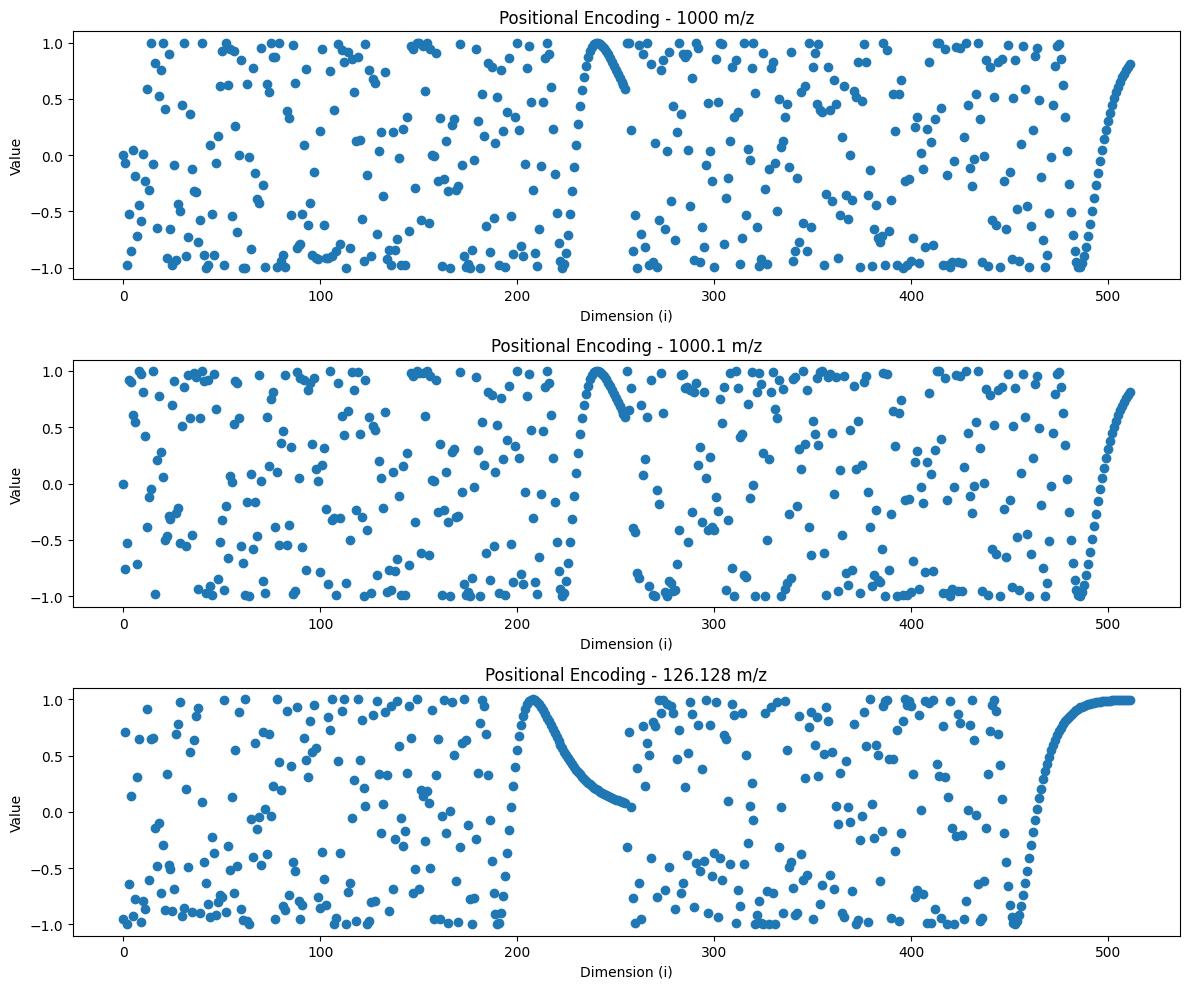

In [39]:
encode_1 = positional_encoding(1000)
encode_2 = positional_encoding(1000.1)
encode_3 = positional_encoding(126.1277)
# plot the encodings as three scatter plots,
import matplotlib.pyplot as plt

# Set the figure size before creating subplots
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.scatter(range(len(encode_1)), encode_1)
plt.title("Positional Encoding - 1000 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(3, 1, 2)
plt.scatter(range(len(encode_2)), encode_2)
plt.title("Positional Encoding - 1000.1 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(3, 1, 3)
plt.scatter(range(len(encode_3)), encode_3)
plt.title("Positional Encoding - 126.128 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()


I only halfway understand what's going on here, so the following explanation should be taken with a grain of salt

The positional encoding attempts to capture both high-resolution information and low-resolution information.

Dimensions ~200-255 and ~450-500 capture low resolution information. They will only differ if there is a large m/z difference between the encoded values.

Dimensions 0-50 and 256-300 encoded high resolution information. They change even if the m/z values are very close together

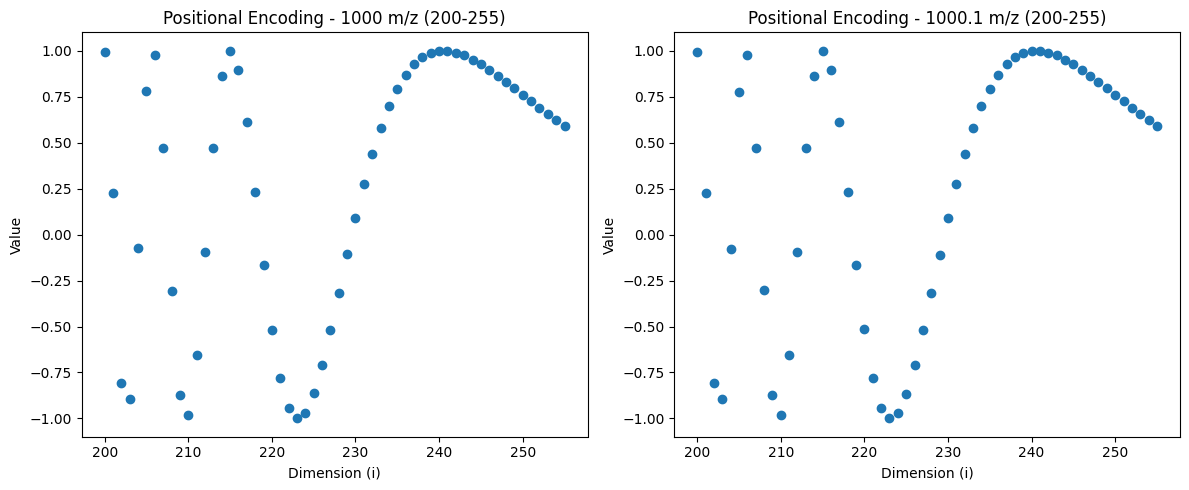

Cosine Similarity (1000 m/z vs 1000.1 m/z): 0.9999997415834383


In [40]:
# for encode_1 and encode_2, plot the values from 200 to 255
# and calculate the cosine similarity between the two
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(200, 256), encode_1[200:256])
plt.title("Positional Encoding - 1000 m/z (200-255)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.scatter(range(200, 256), encode_2[200:256])
plt.title("Positional Encoding - 1000.1 m/z (200-255)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity between the two encodings
cosine_sim = cosine_similarity([encode_1[200:256]], [encode_2[200:256]])
print("Cosine Similarity (1000 m/z vs 1000.1 m/z):", cosine_sim[0][0])

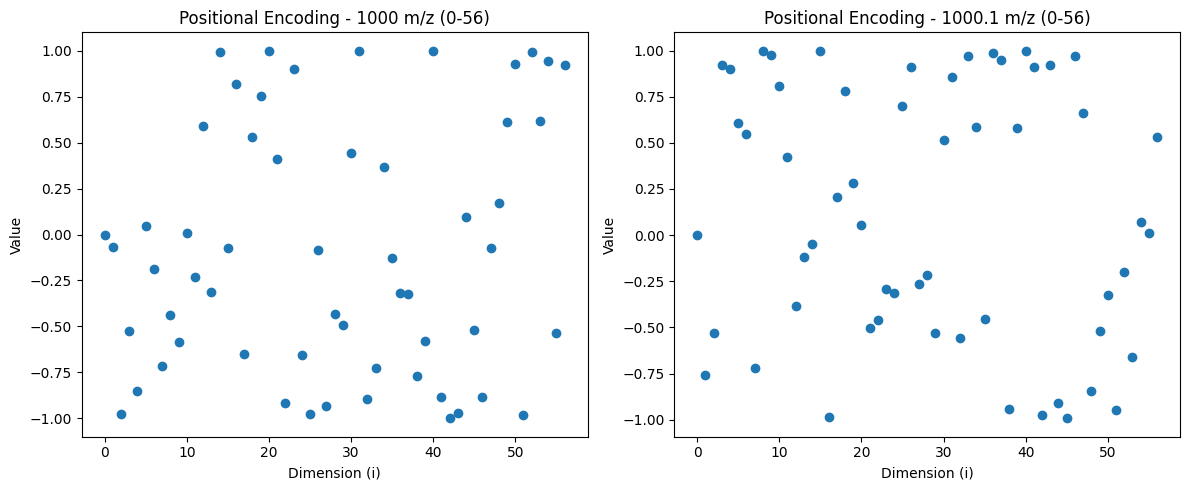

Cosine Similarity (1000 m/z vs 1000.1 m/z): -0.041003839526107325


In [41]:
# Repeat the above plots and calculations, but this time only consider the range from 0 to 56
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(0, 57), encode_1[0:57])
plt.title("Positional Encoding - 1000 m/z (0-56)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.scatter(range(0, 57), encode_2[0:57])
plt.title("Positional Encoding - 1000.1 m/z (0-56)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

# Calculate cosine similarity between the two encodings
cosine_sim = cosine_similarity([encode_1[0:57]], [encode_2[0:57]])
print("Cosine Similarity (1000 m/z vs 1000.1 m/z):", cosine_sim[0][0])